In [13]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from datetime import datetime, timedelta, date
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

In [2]:
df_clickstream = pd.read_csv('data/feature_clickstream.csv')
df_attribute = pd.read_csv('data/features_attributes.csv')
df_financials = pd.read_csv('data/features_financials.csv')
df_loan = pd.read_csv('data/lms_loan_daily.csv')

### Clickstream

In [6]:
df_clickstream.describe()

,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
count,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000
mean,101.414796,103.096195,104.333709,105.648503,106.996676,103.235922,107.070337,110.718724,114.406354,117.775797,99.615537,99.823680,100.420804,100.025801,99.600383,99.860834,100.129425,100.125139,100.341162,100.046259
std,99.833594,99.930002,100.599865,100.326065,100.693607,100.270388,100.323265,100.243698,100.186139,100.807686,100.335428,100.591175,100.881826,101.070371,101.145906,100.751876,101.298428,102.231587,102.666804,103.589358
min,-378.000000,-356.000000,-399.000000,-307.000000,-343.000000,-321.000000,-368.000000,-361.000000,-328.000000,-317.000000,-375.000000,-344.000000,-355.000000,-394.000000,-351.000000,-342.000000,-329.000000,-344.000000,-401.000000,-354.000000
25%,34.000000,36.000000,36.000000,38.000000,39.000000,36.000000,39.000000,43.000000,47.000000,50.000000,32.000000,32.000000,33.000000,32.000000,31.000000,32.000000,32.000000,31.000000,31.000000,30.000000
50%,102.000000,103.000000,104.000000,106.000000,107.000000,103.000000,107.000000,111.000000,115.000000,118.000000,100.000000,100.000000,101.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
75%,169.000000,171.000000,172.000000,173.000000,175.000000,171.000000,174.000000,179.000000,182.000000,186.000000,167.000000,168.000000,168.000000,168.000000,168.000000,168.000000,169.000000,169.000000,170.000000,170.000000
max,541.000000,560.000000,583.000000,562.000000,570.000000,565.000000,537.000000,573.000000,577.000000,537.000000,613.000000,550.000000,530.000000,583.000000,597.000000,554.000000,516.000000,551.000000,560.000000,547.000000


In [3]:
df_clickstream.head()

,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,63,118,80,121,55,193,111,112,-101,83,...,-16,-81,-126,114,35,85,-73,76,CUS_0x1037,2023-01-01
1,-108,182,123,4,-56,27,25,-6,284,222,...,-14,-96,200,35,130,94,111,75,CUS_0x1069,2023-01-01
2,-13,8,87,166,214,-98,215,152,129,139,...,26,86,171,125,-130,354,17,302,CUS_0x114a,2023-01-01
3,-85,45,200,89,128,54,76,51,61,139,...,172,96,174,163,37,207,180,118,CUS_0x1184,2023-01-01
4,55,120,226,-86,253,97,107,68,103,126,...,76,43,183,159,-26,104,118,184,CUS_0x1297,2023-01-01


In [4]:
df_clickstream.groupby('snapshot_date').size()

snapshot_date
2023-01-01    8974
2023-02-01    8974
2023-03-01    8974
2023-04-01    8974
2023-05-01    8974
2023-06-01    8974
2023-07-01    8974
2023-08-01    8974
2023-09-01    8974
2023-10-01    8974
2023-11-01    8974
2023-12-01    8974
2024-01-01    8974
2024-02-01    8974
2024-03-01    8974
2024-04-01    8974
2024-05-01    8974
2024-06-01    8974
2024-07-01    8974
2024-08-01    8974
2024-09-01    8974
2024-10-01    8974
2024-11-01    8974
2024-12-01    8974
dtype: int64

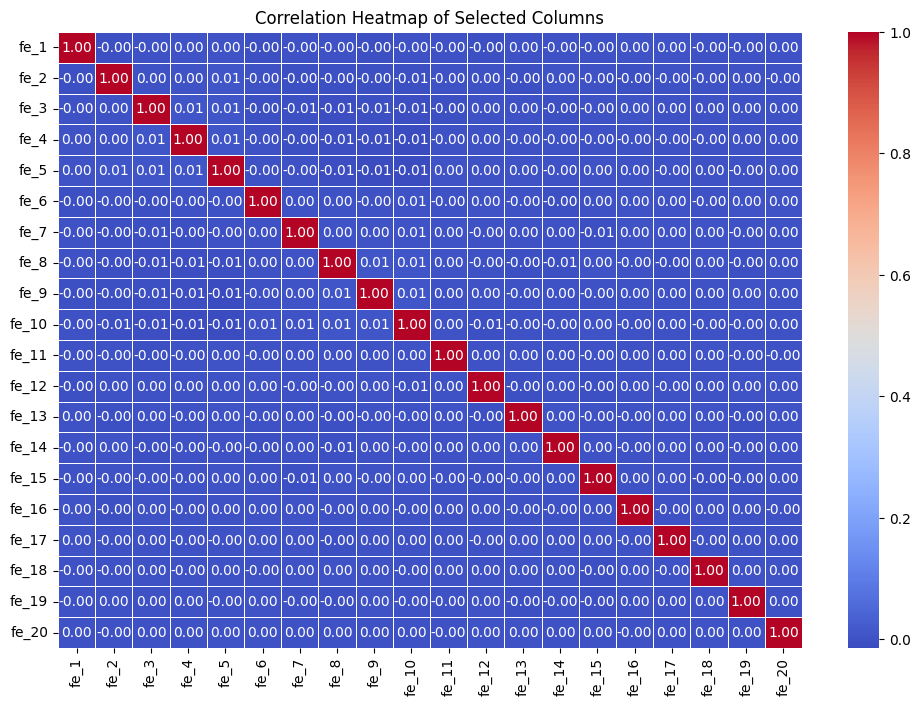

In [17]:
columns_to_correlate = [c for c in df_clickstream.columns if c not in ['Customer_ID', 'snapshot_date']]
subset_df = df_clickstream[columns_to_correlate]
correlation_matrix = subset_df.corr()

plt.figure(figsize=(12, 8)) # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Selected Columns')
plt.show()

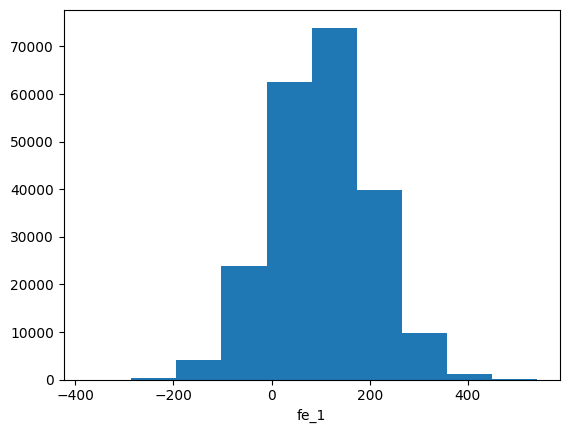

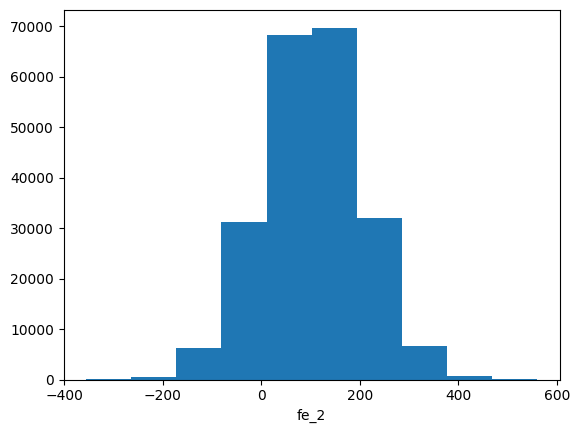

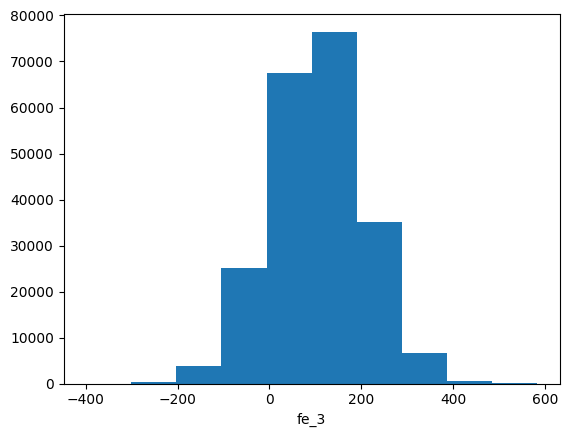

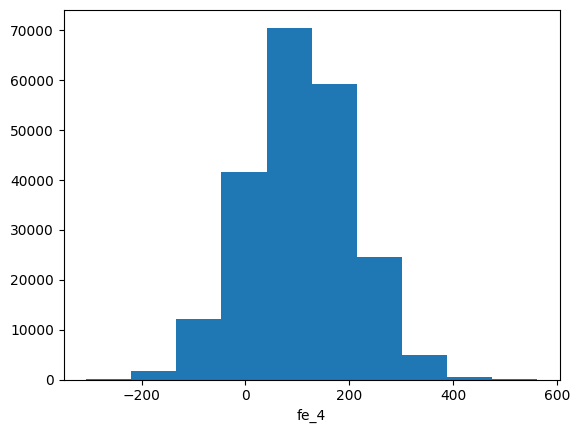

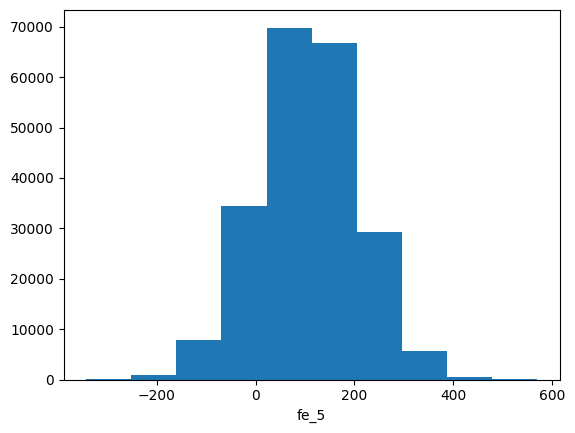

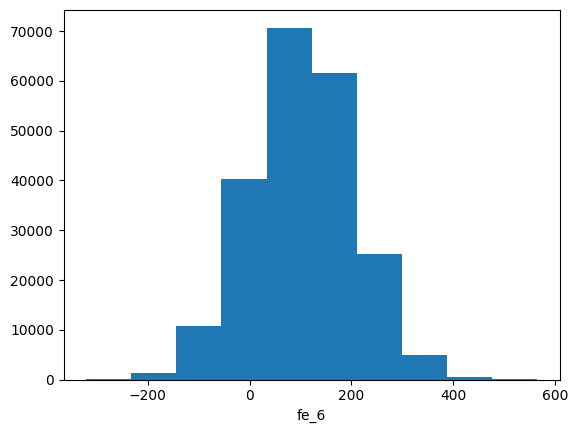

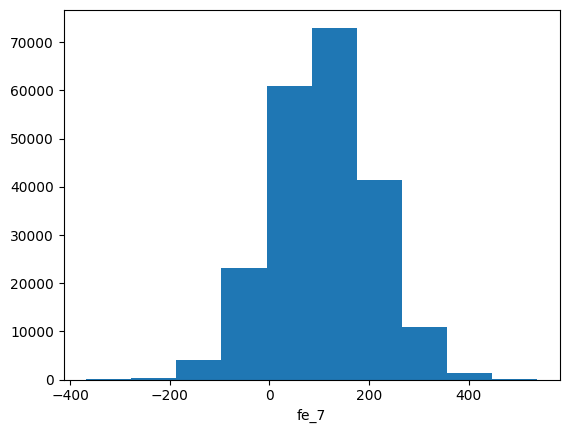

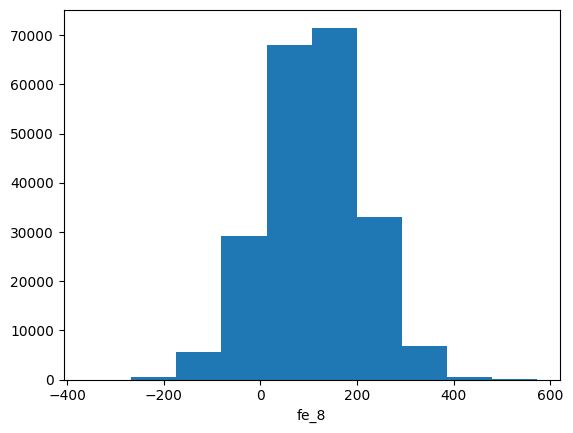

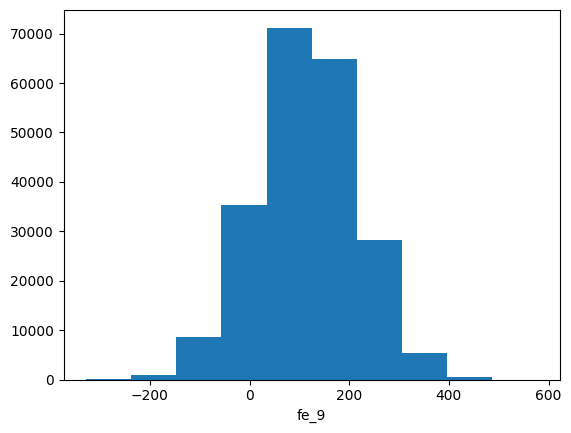

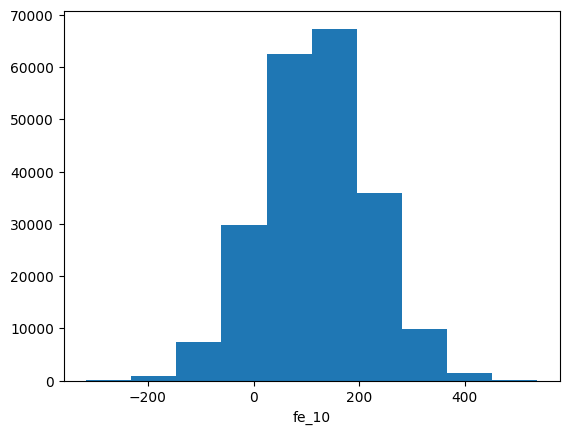

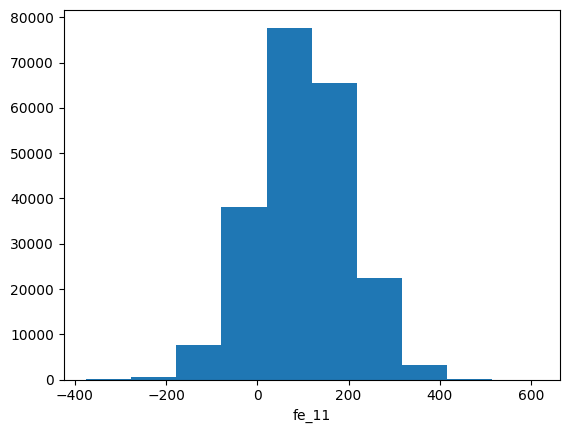

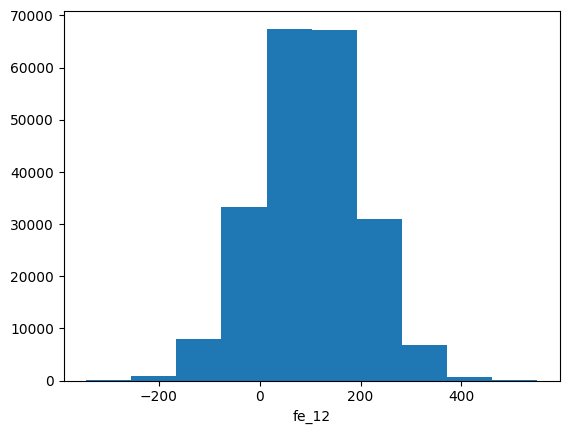

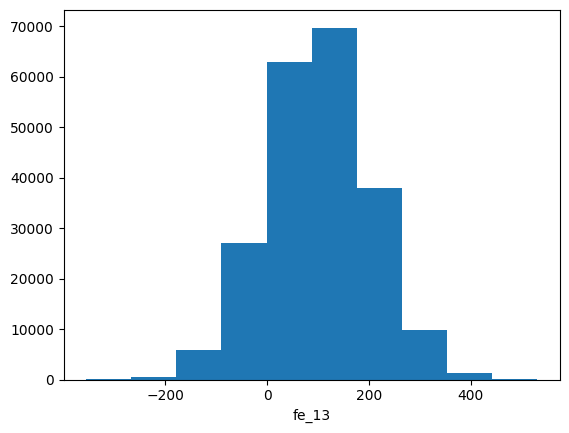

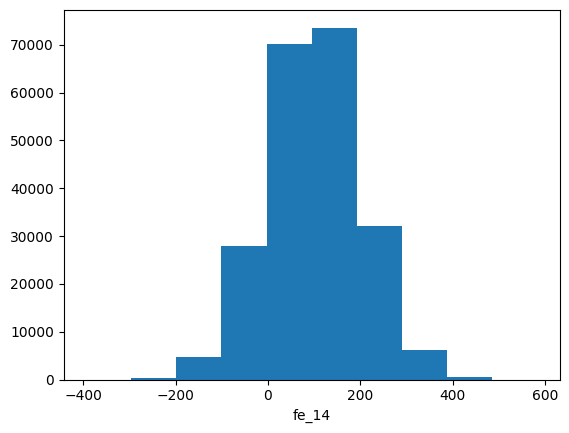

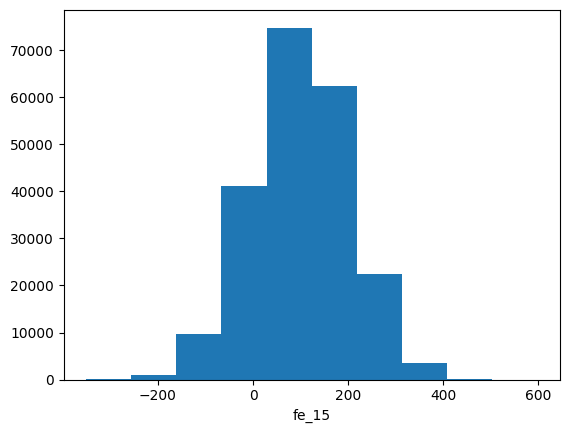

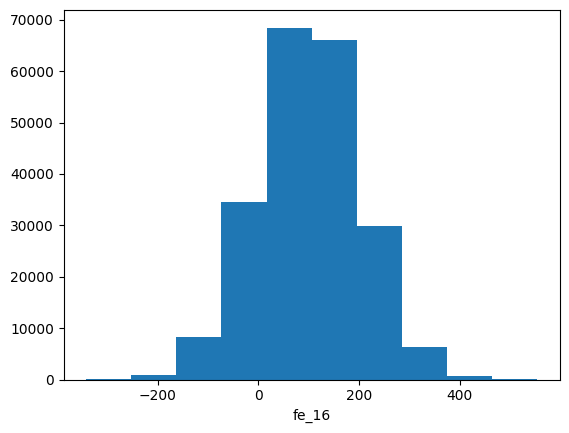

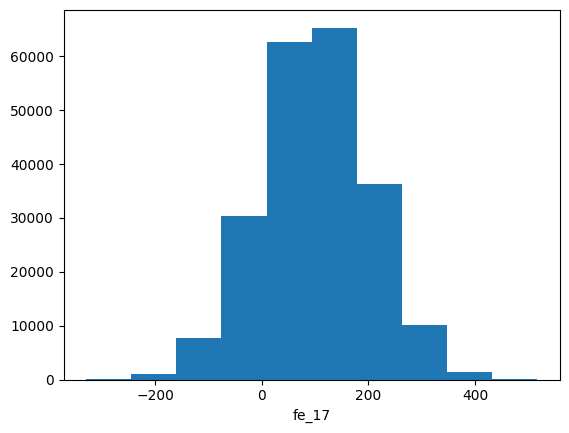

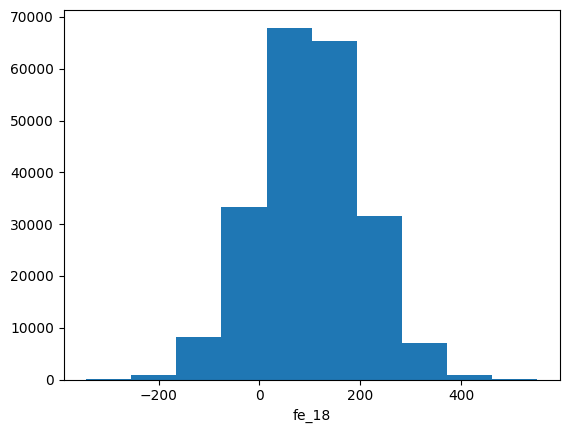

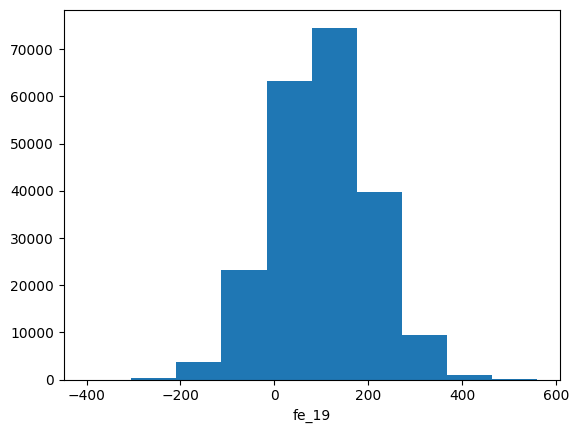

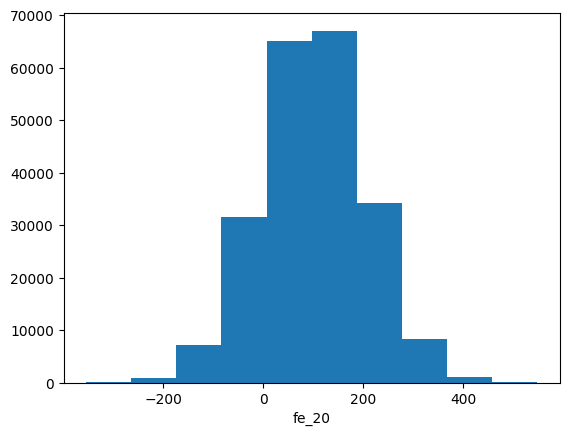

In [11]:
for x in [c for c in df_clickstream.columns if c not in ['Customer_ID', 'snapshot_date']]:
    plt.hist(df_clickstream[x])
    plt.xlabel(x)
    plt.show()

### Loans

In [8]:
df_loan.describe()

,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance
count,137500.0,137500.000000,137500.0,137500.000000,137500.000000,137500.000000,137500.000000
mean,10.0,5.000000,10000.0,909.090909,711.810909,871.905455,5871.905455
std,0.0,3.162289,0.0,287.480833,485.726859,2002.672544,3070.777575
min,10.0,0.000000,10000.0,0.000000,0.000000,0.000000,0.000000
25%,10.0,2.000000,10000.0,1000.000000,0.000000,0.000000,3000.000000
50%,10.0,5.000000,10000.0,1000.000000,1000.000000,0.000000,7000.000000
75%,10.0,8.000000,10000.0,1000.000000,1000.000000,0.000000,8000.000000
max,10.0,10.000000,10000.0,1000.000000,4000.000000,10000.000000,10000.000000


In [9]:
df_loan.head()

,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,0,10000,0.0,0.0,0.0,10000.0,2023-05-01
1,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,1,10000,1000.0,1000.0,0.0,9000.0,2023-06-01
2,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2023-07-01
3,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,3,10000,1000.0,0.0,1000.0,8000.0,2023-08-01
4,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,4,10000,1000.0,2000.0,0.0,6000.0,2023-09-01


In [12]:
df_loan.groupby('snapshot_date').size()

snapshot_date
2023-01-01     530
2023-02-01    1031
2023-03-01    1537
2023-04-01    2047
2023-05-01    2568
2023-06-01    3085
2023-07-01    3556
2023-08-01    4037
2023-09-01    4491
2023-10-01    4978
2023-11-01    5469
2023-12-01    5428
2024-01-01    5412
2024-02-01    5424
2024-03-01    5425
2024-04-01    5417
2024-05-01    5391
2024-06-01    5418
2024-07-01    5442
2024-08-01    5531
2024-09-01    5537
2024-10-01    5502
2024-11-01    5501
2024-12-01    5531
2025-01-01    5539
2025-02-01    5028
2025-03-01    4515
2025-04-01    4024
2025-05-01    3526
2025-06-01    3021
2025-07-01    2478
2025-08-01    1985
2025-09-01    1529
2025-10-01    1041
2025-11-01     526
dtype: int64

In [13]:
df_loan[df_loan.installment_num>=6].groupby('snapshot_date').size()

snapshot_date
2023-07-01     530
2023-08-01    1031
2023-09-01    1537
2023-10-01    2047
2023-11-01    2568
2023-12-01    2555
2024-01-01    2525
2024-02-01    2500
2024-03-01    2444
2024-04-01    2410
2024-05-01    2384
2024-06-01    2402
2024-07-01    2406
2024-08-01    2470
2024-09-01    2494
2024-10-01    2516
2024-11-01    2518
2024-12-01    2531
2025-01-01    2518
2025-02-01    2550
2025-03-01    2530
2025-04-01    2495
2025-05-01    2485
2025-06-01    2495
2025-07-01    2478
2025-08-01    1985
2025-09-01    1529
2025-10-01    1041
2025-11-01     526
dtype: int64

In [19]:
pd.options.display.max_rows
df_loan.groupby('Customer_ID')['snapshot_date'].min()

Customer_ID
CUS_0x1000    2023-05-01
CUS_0x1009    2025-01-01
CUS_0x100b    2024-03-01
CUS_0x1011    2023-11-01
CUS_0x1013    2023-12-01
                 ...    
CUS_0xff3     2024-06-01
CUS_0xff4     2024-12-01
CUS_0xff6     2024-10-01
CUS_0xffc     2024-01-01
CUS_0xffd     2024-03-01
Name: snapshot_date, Length: 12500, dtype: object

In [22]:
df_loan[df_loan['Customer_ID']=='CUS_0x100b']

,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
22,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,0,10000,0.0,0.0,0.0,10000.0,2024-03-01
23,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,1,10000,1000.0,1000.0,0.0,9000.0,2024-04-01
24,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2024-05-01
25,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,3,10000,1000.0,1000.0,0.0,7000.0,2024-06-01
26,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,4,10000,1000.0,1000.0,0.0,6000.0,2024-07-01
27,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,5,10000,1000.0,1000.0,0.0,5000.0,2024-08-01
28,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,6,10000,1000.0,1000.0,0.0,4000.0,2024-09-01
29,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,7,10000,1000.0,1000.0,0.0,3000.0,2024-10-01
30,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,8,10000,1000.0,1000.0,0.0,2000.0,2024-11-01
31,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000,1000.0,1000.0,0.0,1000.0,2024-12-01


### Financials

In [14]:
df_financials.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000
mean,4188.592303,16.939920,23.172720,73.213360,21.060880,26.695280,32.349265,1488.394291
std,3180.147611,114.350815,132.005866,468.682227,14.863091,184.193829,5.156815,8561.449910
min,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.100770,0.000000
25%,1624.937917,3.000000,4.000000,8.000000,10.000000,4.000000,28.066517,31.496968
50%,3087.595000,6.000000,5.000000,14.000000,18.000000,6.000000,32.418953,72.887628
75%,5947.364167,7.000000,7.000000,20.000000,28.000000,10.000000,36.623650,169.634826
max,15204.633333,1756.000000,1499.000000,5789.000000,67.000000,2554.000000,48.199824,81971.000000


In [7]:
df_financials.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               12500 non-null  object 
 1   Annual_Income             12500 non-null  object 
 2   Monthly_Inhand_Salary     12500 non-null  float64
 3   Num_Bank_Accounts         12500 non-null  int64  
 4   Num_Credit_Card           12500 non-null  int64  
 5   Interest_Rate             12500 non-null  int64  
 6   Num_of_Loan               12500 non-null  object 
 7   Type_of_Loan              11074 non-null  object 
 8   Delay_from_due_date       12500 non-null  int64  
 9   Num_of_Delayed_Payment    12500 non-null  object 
 10  Changed_Credit_Limit      12246 non-null  object 
 11  Num_Credit_Inquiries      12500 non-null  float64
 12  Credit_Mix                12500 non-null  object 
 13  Outstanding_Debt          12500 non-null  object 
 14  Credit

In [15]:
df_financials.head()

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x1000,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, and Home Equity Loan",57,26,...,Bad,1562.91,30.077191,10 Years and 9 Months,Yes,42.941090,77.31427572208112,High_spent_Medium_value_payments,400.36080052211616,2023-05-01
1,CUS_0x1009,52312.68_,4250.390000,6,5,17,4,"Not Specified, Home Equity Loan, Credit-Builde...",5,18,...,_,202.68,40.286997,31 Years and 0 Months,Yes,108.366467,58.66019164829086,High_spent_Medium_value_payments,508.01234122645366,2025-01-01
2,CUS_0x100b,113781.38999999998,9549.782500,1,4,1,0,NaN,14,8,...,Good,1030.2,28.592943,15 Years and 10 Months,No,0.000000,617.0792665202719,High_spent_Small_value_payments,597.8989834797281,2024-03-01
3,CUS_0x1011,58918.47,5208.872500,3,3,17,3,"Student Loan, Credit-Builder Loan, and Debt Co...",27,13,...,Standard,473.14,27.829959,15 Years and 10 Months,Yes,123.434939,383.35084463651407,Low_spent_Medium_value_payments,294.1014665671429,2023-11-01
4,CUS_0x1013,98620.98,7962.415000,3,3,6,3,"Student Loan, Debt Consolidation Loan, and Per...",12,9,...,Good,1233.51,26.524864,17 Years and 10 Months,No,228.018084,332.3337079767732,High_spent_Medium_value_payments,485.8897083704929,2023-12-01


In [16]:
df_financials.groupby('snapshot_date').size()

snapshot_date
2023-01-01    530
2023-02-01    501
2023-03-01    506
2023-04-01    510
2023-05-01    521
2023-06-01    517
2023-07-01    471
2023-08-01    481
2023-09-01    454
2023-10-01    487
2023-11-01    491
2023-12-01    489
2024-01-01    485
2024-02-01    518
2024-03-01    511
2024-04-01    513
2024-05-01    491
2024-06-01    498
2024-07-01    505
2024-08-01    543
2024-09-01    493
2024-10-01    456
2024-11-01    488
2024-12-01    515
2025-01-01    526
dtype: int64

In [25]:
pd.set_option('display.max_columns', None)
df_financials[df_financials['Customer_ID']=='CUS_0x100b']

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
2,CUS_0x100b,113781.38999999998,9549.7825,1,4,1,0,NaN,14,8,8.34,4.0,Good,1030.2,28.592943,15 Years and 10 Months,No,0.0,617.0792665202719,High_spent_Small_value_payments,597.8989834797281,2024-03-01


In [3]:
df_financials['Credit_Mix'].unique()

array(['Bad', '_', 'Good', 'Standard'], dtype=object)

In [4]:
cols_num = ['Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date','Num_of_Delayed_Payment','Changed_Credit_Limit','Outstanding_Debt','Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance']

for x in cols_num:
    df_financials[x] = df_financials[x].replace("_", "")

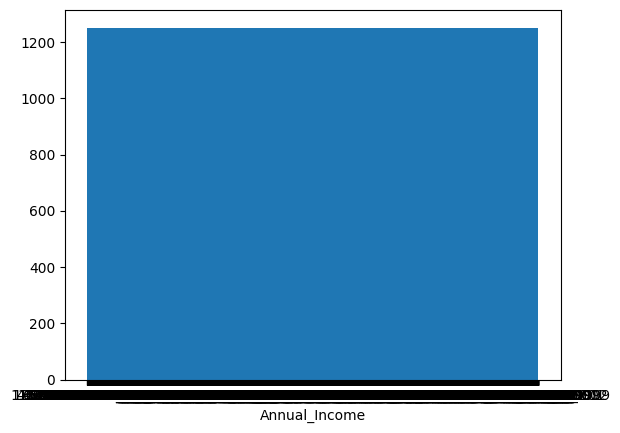

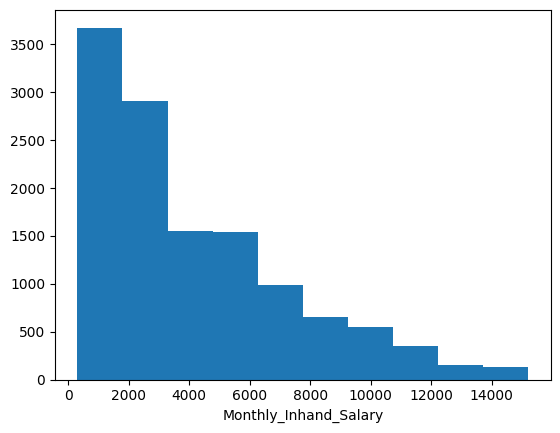

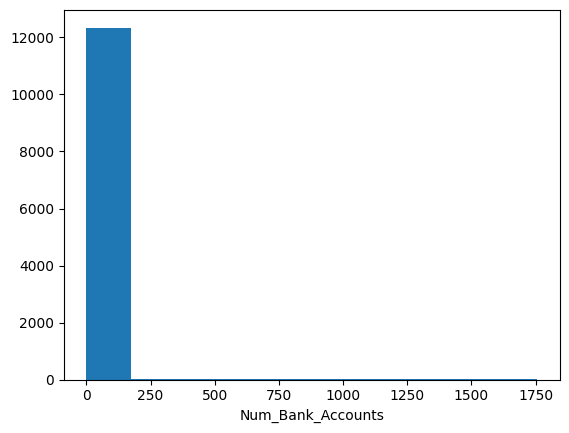

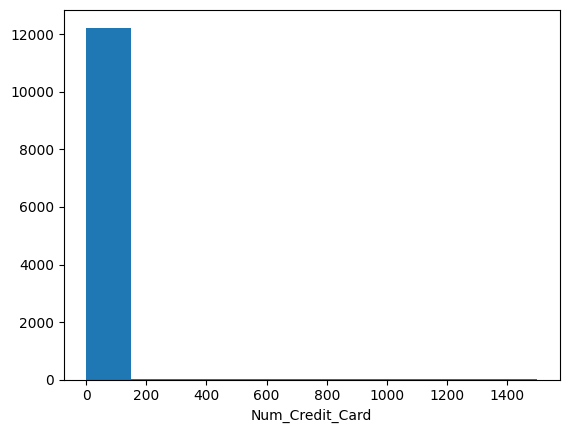

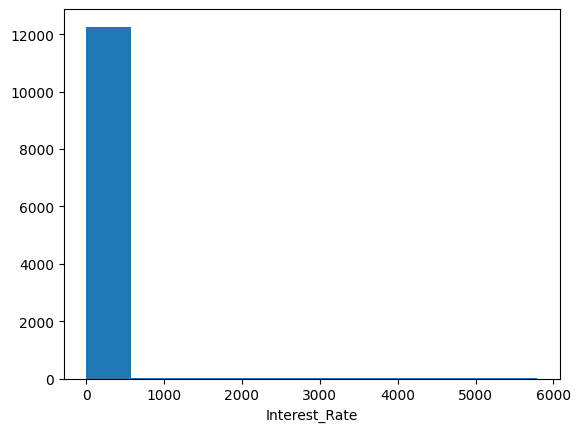

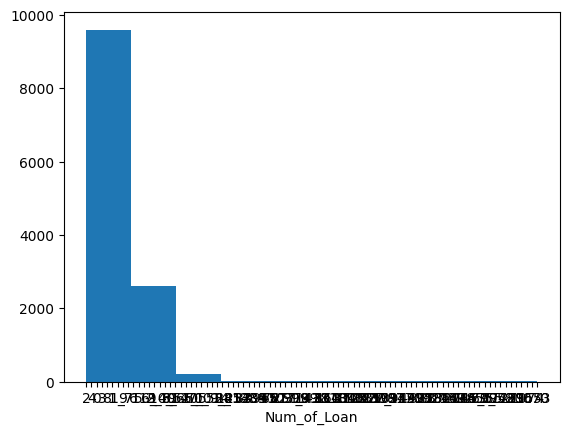

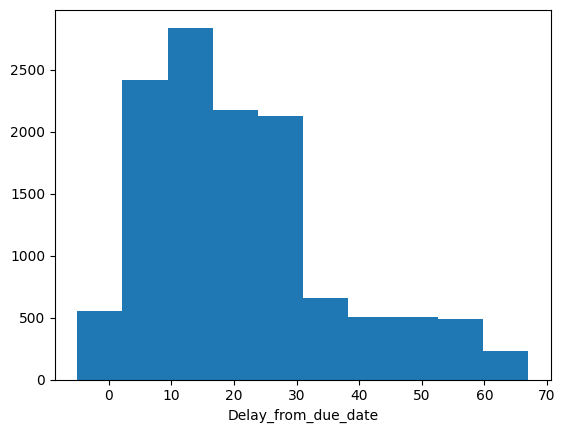

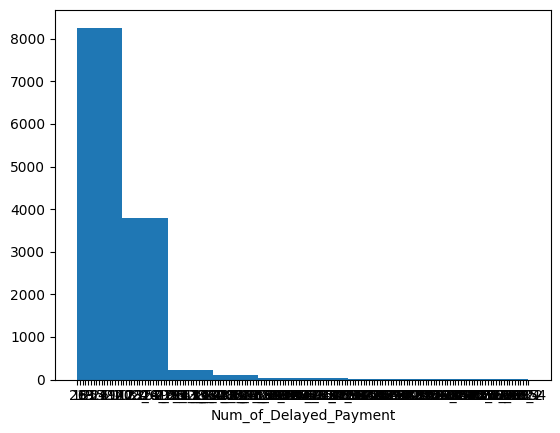

TypeError: 'value' must be an instance of str or bytes, not a None

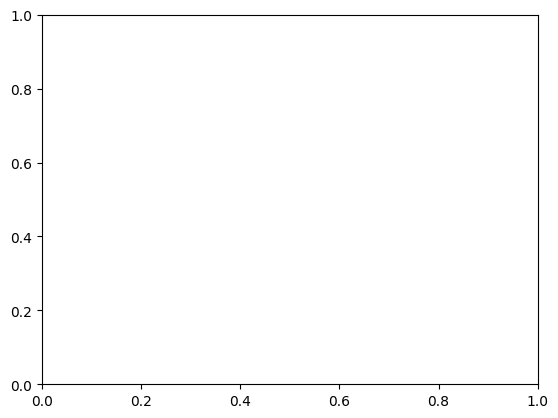

In [6]:
for x in cols_num:
    plt.hist(df_financials[x])
    plt.xlabel(x)
    plt.show()

### Attributes

In [23]:
df_attribute[df_attribute['Customer_ID']=='CUS_0x100b']

,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
2,CUS_0x100b,Shirboni,19,#F%$D@*&8,Media_Manager,2024-03-01


In [21]:
snapshot_date_str = '2023-07-01'
snapshot_date = datetime.strptime(snapshot_date_str, "%Y-%m-%d")
silver_directory = "datamart/silver/features_clickstream/"

paths = []
for i in range(1, 7):
    m = snapshot_date - relativedelta(months=i)
    partition_name = "silver_features_clickstream_" + m.strftime('%Y_%m_%d') + '.parquet'
    filepath = silver_directory + partition_name
    print('loaded from:', filepath)

    paths.append((i, filepath))  # (months_ago, path)

loaded from: datamart/silver/features_clickstream/silver_features_clickstream_2023_06_01.parquet
loaded from: datamart/silver/features_clickstream/silver_features_clickstream_2023_05_01.parquet
loaded from: datamart/silver/features_clickstream/silver_features_clickstream_2023_04_01.parquet
loaded from: datamart/silver/features_clickstream/silver_features_clickstream_2023_03_01.parquet
loaded from: datamart/silver/features_clickstream/silver_features_clickstream_2023_02_01.parquet
loaded from: datamart/silver/features_clickstream/silver_features_clickstream_2023_01_01.parquet


In [29]:
paths

[(1,
  'datamart/silver/features_clickstream/silver_features_clickstream_2023_06_01.parquet'),
 (2,
  'datamart/silver/features_clickstream/silver_features_clickstream_2023_05_01.parquet'),
 (3,
  'datamart/silver/features_clickstream/silver_features_clickstream_2023_04_01.parquet'),
 (4,
  'datamart/silver/features_clickstream/silver_features_clickstream_2023_03_01.parquet'),
 (5,
  'datamart/silver/features_clickstream/silver_features_clickstream_2023_02_01.parquet'),
 (6,
  'datamart/silver/features_clickstream/silver_features_clickstream_2023_01_01.parquet')]

In [34]:
import pyspark
import pyspark.sql.functions as F

# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/26 15:50:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/10/26 15:50:12 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [37]:
dfs = []
for months_ago, p in paths:
    try:
        df = (spark.read.parquet(p)
                .select(F.col("Customer_ID").cast("string"),
                        F.col("fe_1").cast("double"))
                .withColumn("months_ago", F.lit(months_ago)))
        dfs.append(df)
    except Exception:
        # File may be missing; just skip it
        pass

In [38]:
dfs

[DataFrame[Customer_ID: string, fe_1: double, months_ago: int],
 DataFrame[Customer_ID: string, fe_1: double, months_ago: int],
 DataFrame[Customer_ID: string, fe_1: double, months_ago: int],
 DataFrame[Customer_ID: string, fe_1: double, months_ago: int],
 DataFrame[Customer_ID: string, fe_1: double, months_ago: int],
 DataFrame[Customer_ID: string, fe_1: double, months_ago: int]]